In [31]:
# setup: imports, run settings, paths
import os, sys, json, zipfile, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

DEBUG = False
RUN_FOLDS = [0, 1, 2, 3, 4]
HEAD_EPOCHS = 50

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT = Path("/content/drive/MyDrive/AircraftDefectDetection")
    get_ipython().run_line_magic("pip", "install -q timm git+https://github.com/Blealtan/efficient-kan.git")
    DATA_DIR = Path("/content/Aircraft_Defect_Image_Dataset")
    if not DATA_DIR.exists():
        tmp = Path("/content/_unzip"); tmp.mkdir(exist_ok=True)
        with zipfile.ZipFile(PROJECT / "Aircraft_Defect_Image_Dataset.zip") as z:
            z.extractall(tmp)
        DATA_DIR = next(p.parent for p in tmp.rglob("train") if p.is_dir())
    CACHE_DIR = Path("/content/cache")
else:
    cwd = Path.cwd()
    PROJECT = cwd.parent if cwd.name == "notebooks" else cwd
    DATA_DIR = PROJECT / "Aircraft_Defect_Image_Dataset"
    CACHE_DIR = PROJECT / "outputs" / "cache"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [32]:
# imports
import copy
import hashlib
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2

In [33]:
# constants and default settings
IMG_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

BACKBONES = {
    "resnet50": "resnet50.tv_in1k",
    "densenet121": "densenet121.tv_in1k",
    "tinyvit5m": "tiny_vit_5m_224.dist_in22k_ft_in1k",
}

DEFAULT_CFG = dict(
    epochs=20,
    batch_size=32,
    lr=1e-4,
    weight_decay=1e-4,
    focal_gamma=1.5,
    label_smoothing=0.15,
    head_dropout=0.5,
    plateau_factor=0.5,
    plateau_patience=5,
    num_workers=2,
    amp=True,
    seed=42,
    debug_n=None,
    head_lr=1e-3,
    head_epochs=50,
    head_batch=64,
    stream_dropout=0.3,
    kan_hidden=(256, 128),
    kan_grid=3,
    kan_order=3,
)

In [34]:
# data loading and augmentation
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def load_splits(splits_dir):
    splits_dir = Path(splits_dir)
    df = pd.read_csv(splits_dir / "data_splits.csv")
    with open(splits_dir / "split_config.json") as fh:
        cfg = json.load(fh)
    return df, cfg


def build_image_cache(df, data_dir, cache_dir, size=IMG_SIZE):
    """Decode + resize every image once and keep it as a uint8 array (N, size, size, 3)."""
    key = hashlib.md5("|".join(df.path).encode()).hexdigest()[:8]
    cache_file = Path(cache_dir) / f"images_{size}_{key}.npy"
    if cache_file.exists():
        return np.load(cache_file)
    arr = np.zeros((len(df), size, size, 3), np.uint8)
    for i, p in enumerate(df.path):
        with Image.open(Path(data_dir) / p) as im:
            arr[i] = np.asarray(im.convert("RGB").resize((size, size), Image.BICUBIC))
    cache_file.parent.mkdir(parents=True, exist_ok=True)
    np.save(cache_file, arr)
    return arr


def make_transforms(train):
    norm = v2.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    if not train:
        return v2.Compose([v2.ToDtype(torch.float32, scale=True), norm])
    return v2.Compose([
        v2.RandomHorizontalFlip(0.5),
        v2.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.15, contrast=0.15),
        v2.ToDtype(torch.float32, scale=True),
        norm,
    ])


class ArrayDataset(Dataset):
    def __init__(self, images, labels, idx, transform):
        self.images, self.labels, self.idx, self.t = images, labels, np.asarray(idx), transform

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = int(self.idx[i])
        x = torch.from_numpy(self.images[j]).permute(2, 0, 1).contiguous()
        return self.t(x), int(self.labels[j]), j


def make_loaders(df, images, fold, cfg, device):
    role = df[f"role_f{fold}"].values
    labels = df.label_id.values
    rng = np.random.RandomState(cfg["seed"] + fold)
    parts = {}
    for r in ["train", "val", "test"]:
        idx = np.nonzero(role == r)[0]
        if cfg["debug_n"] and len(idx) > cfg["debug_n"]:
            idx = rng.choice(idx, cfg["debug_n"], replace=False)
        parts[r] = idx
    pin = device.type == "cuda"
    nw = cfg["num_workers"]
    kw = dict(num_workers=nw, pin_memory=pin, persistent_workers=nw > 0)
    loaders = {
        "train": DataLoader(ArrayDataset(images, labels, parts["train"], make_transforms(True)),
                            batch_size=cfg["batch_size"], shuffle=True, drop_last=True, **kw),
        "val": DataLoader(ArrayDataset(images, labels, parts["val"], make_transforms(False)),
                          batch_size=cfg["batch_size"] * 2, shuffle=False, **kw),
        "test": DataLoader(ArrayDataset(images, labels, parts["test"], make_transforms(False)),
                           batch_size=cfg["batch_size"] * 2, shuffle=False, **kw),
    }
    return loaders, parts

In [35]:
# models
class Stream(nn.Module):
    """One pretrained backbone that returns a pooled feature vector; early layers are frozen."""

    def __init__(self, key, pretrained=True):
        super().__init__()
        self.key = key
        self.net = timm.create_model(BACKBONES[key], pretrained=pretrained, num_classes=0)
        self.dim = self.net.num_features
        self.frozen = self._freeze_early()

    def _freeze_early(self):
        n = self.net
        if self.key == "resnet50":
            mods = [n.conv1, n.bn1, n.layer1]
        elif self.key == "densenet121":
            f = n.features
            mods = [f.conv0, f.norm0, f.denseblock1, f.transition1]
        elif self.key == "tinyvit5m":
            mods = [n.patch_embed, n.stages[0]]
        else:
            raise ValueError(self.key)
        for m in mods:
            for p in m.parameters():
                p.requires_grad = False
        return mods

    def forward(self, x):
        return self.net(x)


class SingleModel(nn.Module):

    def __init__(self, key, num_classes, dropout=0.5, pretrained=True):
        super().__init__()
        self.stream = Stream(key, pretrained)
        d = self.stream.dim
        self.head = nn.Sequential(nn.BatchNorm1d(d), nn.Dropout(dropout), nn.Linear(d, num_classes))

    def streams(self):
        return [self.stream]

    def forward(self, x):
        return self.head(self.stream(x))


def set_train_mode(model):
    model.train()
    for s in model.streams():
        for m in s.frozen:
            m.eval()

In [36]:
# loss and metrics
class FocalLoss(nn.Module):

    def __init__(self, num_classes, gamma=1.5, smoothing=0.15):
        super().__init__()
        self.k, self.gamma, self.eps = num_classes, gamma, smoothing

    def forward(self, logits, target):
        logp = F.log_softmax(logits.float(), dim=1)
        p = logp.exp()
        y = torch.full_like(logp, self.eps / self.k)
        y.scatter_(1, target[:, None], 1 - self.eps + self.eps / self.k)
        return -(y * (1 - p).pow(self.gamma) * logp).sum(dim=1).mean()

def compute_metrics(y_true, y_pred, classes):
    labels = list(range(len(classes)))
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    return dict(
        accuracy=float(accuracy_score(y_true, y_pred)),
        macro_precision=float(np.mean(p)),
        macro_recall=float(np.mean(r)),
        macro_f1=float(f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)),
        weighted_f1=float(f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)),
        per_class={c: dict(precision=float(p[i]), recall=float(r[i]), f1=float(f[i]), support=int(s[i]))
                   for i, c in enumerate(classes)},
        confusion=confusion_matrix(y_true, y_pred, labels=labels).tolist(),
    )


@torch.no_grad()
def predict_logits(model, loader, device, amp=True):
    model.eval()
    out, ys, idx = [], [], []
    use_amp = amp and device.type == "cuda"
    for x, y, j in loader:
        x = x.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            out.append(model(x).float().cpu())
        ys.append(y)
        idx.append(j)
    return torch.cat(out), torch.cat(ys).numpy(), torch.cat(idx).numpy()

In [37]:
# efficiency: parameters, flops, latency
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return dict(params_total_M=total / 1e6, params_trainable_M=trainable / 1e6)


def count_gflops(model, device):
    """FLOPs of one 224x224 forward pass, in GFLOPs (torch counts a multiply-add as 2 FLOPs)."""
    try:
        from torch.utils.flop_counter import FlopCounterMode
        model.eval()
        x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
        with torch.no_grad(), FlopCounterMode(display=False) as fc:
            model(x)
        return fc.get_total_flops() / 1e9
    except Exception as e:
        print("FLOP count failed:", e)
        return None


@torch.no_grad()
def inference_ms(model, device, warmup=10, runs=50):
    """Mean latency of a single-image (batch 1) fp32 forward pass."""
    model.eval()
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    for _ in range(warmup):
        model(x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(runs):
        model(x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / runs * 1000

In [38]:
# training loop for the fine-tuned models
def train_fold(build_model, tag, df, images, fold, classes, cfg, device, out_dir, ckpt_dir=None, log=print):
    """Train on the fold's `train` role, pick the epoch by validation macro-F1, report on the fold's test role.

    Saves <out_dir>/<tag>_fold<k>.json and <out_dir>/preds_<tag>_fold<k>.csv. Returns the result dict.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    seed_everything(cfg["seed"] + fold)
    loaders, parts = make_loaders(df, images, fold, cfg, device)
    log(f"[{tag} fold {fold}] train {len(parts['train'])} | val {len(parts['val'])} | test {len(parts['test'])}")

    model = build_model().to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=cfg["plateau_factor"],
                                                      patience=cfg["plateau_patience"])
    crit = FocalLoss(len(classes), cfg["focal_gamma"], cfg["label_smoothing"])
    use_amp = cfg["amp"] and device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best = dict(f1=-1.0, loss=1e9, epoch=-1, state=None)
    history = []
    t_start = time.time()
    for ep in range(1, cfg["epochs"] + 1):
        set_train_mode(model)
        run_loss, n_seen = 0.0, 0
        for x, y, _ in loaders["train"]:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                logits = model(x)
            loss = crit(logits, y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            run_loss += loss.item() * len(y)
            n_seen += len(y)

        v_logits, v_y, _ = predict_logits(model, loaders["val"], device, cfg["amp"])
        v_loss = crit(v_logits, torch.from_numpy(v_y)).item()
        v_pred = v_logits.argmax(1).numpy()
        v_f1 = f1_score(v_y, v_pred, labels=list(range(len(classes))), average="macro", zero_division=0)
        v_acc = accuracy_score(v_y, v_pred)
        sched.step(v_loss)
        history.append(dict(epoch=ep, train_loss=run_loss / max(n_seen, 1), val_loss=v_loss, val_acc=float(v_acc),
                            val_macro_f1=float(v_f1), lr=opt.param_groups[0]["lr"]))
        log(f"  ep {ep:02d} | train {history[-1]['train_loss']:.4f} | val loss {v_loss:.4f} | "
            f"val acc {v_acc:.4f} | val macro-F1 {v_f1:.4f}")
        if v_f1 > best["f1"] or (v_f1 == best["f1"] and v_loss < best["loss"]):
            best.update(f1=v_f1, loss=v_loss, epoch=ep, state=copy.deepcopy(model.state_dict()))
    train_seconds = time.time() - t_start

    model.load_state_dict(best["state"])
    t_logits, t_y, t_idx = predict_logits(model, loaders["test"], device, cfg["amp"])
    t_prob = F.softmax(t_logits, dim=1).numpy()
    t_pred = t_prob.argmax(1)
    metrics = compute_metrics(t_y, t_pred, classes)
    log(f"  TEST | acc {metrics['accuracy']:.4f} | macro-F1 {metrics['macro_f1']:.4f} (best epoch {best['epoch']})")

    result = dict(tag=tag, fold=fold, best_epoch=best["epoch"], best_val_macro_f1=float(best["f1"]),
                  train_seconds=train_seconds, n_train=len(parts["train"]), n_val=len(parts["val"]),
                  n_test=len(parts["test"]), test=metrics, history=history, cfg={k: v for k, v in cfg.items()},
                  device=str(torch.cuda.get_device_name(0) if device.type == "cuda" else "cpu"))
    result.update(count_params(model))
    result["gflops"] = count_gflops(model, device)
    result["inference_ms"] = inference_ms(model, device)

    with open(out_dir / f"{tag}_fold{fold}.json", "w") as fh:
        json.dump(result, fh, indent=2)
    pred_df = pd.DataFrame(t_prob, columns=[f"prob_{c}" for c in classes])
    pred_df.insert(0, "y_pred", t_pred)
    pred_df.insert(0, "y_true", t_y)
    pred_df.insert(0, "path", df.path.values[t_idx])
    pred_df.to_csv(out_dir / f"preds_{tag}_fold{fold}.csv", index=False)
    if ckpt_dir is not None:
        Path(ckpt_dir).mkdir(parents=True, exist_ok=True)
        torch.save(best["state"], Path(ckpt_dir) / f"{tag}_fold{fold}.pt")
    return result


def collect_results(out_dir, tags=None):
    """Load every <tag>_fold<k>.json in out_dir into a DataFrame."""
    rows = []
    for f in sorted(Path(out_dir).glob("*_fold*.json")):
        r = json.load(open(f))
        if tags and r["tag"] not in tags:
            continue
        rows.append(dict(tag=r["tag"], fold=r["fold"], accuracy=r["test"]["accuracy"],
                         macro_precision=r["test"]["macro_precision"], macro_recall=r["test"]["macro_recall"],
                         macro_f1=r["test"]["macro_f1"], weighted_f1=r["test"]["weighted_f1"],
                         best_epoch=r["best_epoch"], train_seconds=r["train_seconds"],
                         params_total_M=r["params_total_M"], params_trainable_M=r["params_trainable_M"],
                         gflops=r["gflops"], inference_ms=r["inference_ms"]))
    return pd.DataFrame(rows)

In [39]:
# feature extraction and backbone cost
FEATURE_DIMS = {"resnet50": 2048, "densenet121": 1024, "tinyvit5m": 320}


@torch.no_grad()
def extract_features(key, images, device, batch_size=64):
    """Pooled features of a frozen ImageNet-pretrained backbone for every (clean, un-augmented) image."""
    net = Stream(key, pretrained=True).to(device).eval()
    mean = torch.tensor(IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=device).view(1, 3, 1, 1)
    use_amp = device.type == "cuda"
    out = []
    for i in range(0, len(images), batch_size):
        x = torch.from_numpy(images[i:i + batch_size]).to(device).permute(0, 3, 1, 2).float() / 255
        x = (x - mean) / std
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            f = net(x)
        out.append(f.float().cpu())
    return torch.cat(out).numpy()


def backbone_cost(key, device):
    s = Stream(key, pretrained=False).to(device).eval()
    return dict(params_M=sum(p.numel() for p in s.parameters()) / 1e6,
                gflops=count_gflops(s, device), ms=inference_ms(s, device))

In [40]:
# fusion model
class FusionNet(nn.Module):
    def __init__(self, dims, num_classes, head="kan", gated=True, cfg=None):
        super().__init__()
        cfg = cfg or DEFAULT_CFG
        self.dims = list(dims)
        self.gated = gated
        self.bns = nn.ModuleList([nn.BatchNorm1d(d) for d in self.dims])
        self.drop = nn.Dropout(cfg["stream_dropout"])
        self.gates = nn.Parameter(torch.ones(len(self.dims))) if gated else None
        total = sum(self.dims)
        half = total // 2
        self.fuse = nn.Sequential(nn.Linear(total, half), nn.ReLU(), nn.BatchNorm1d(half))
        if head == "kan":
            from efficient_kan import KAN
            self.cls = KAN([half, *cfg["kan_hidden"], num_classes], grid_size=cfg["kan_grid"],
                           spline_order=cfg["kan_order"])
        elif head == "linear":
            self.cls = nn.Sequential(nn.Dropout(cfg["head_dropout"]), nn.Linear(half, num_classes))
        else:
            raise ValueError(head)

    def forward(self, x):
        parts = torch.split(x, self.dims, dim=1)
        w = None
        if self.gated:
            w = self.gates.abs()
            w = w / w.sum()
        z = [self.drop(bn(p)) * (w[i] if w is not None else 1.0) for i, (bn, p) in enumerate(zip(self.bns, parts))]
        return self.cls(self.fuse(torch.cat(z, dim=1)))

    def gate_values(self):
        if not self.gated:
            return None
        w = self.gates.detach().abs()
        return (w / w.sum()).cpu().tolist()


@torch.no_grad()
def _head_ms(model, in_dim, device, warmup=10, runs=50):
    model.eval()
    x = torch.randn(1, in_dim, device=device)
    for _ in range(warmup):
        model(x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(runs):
        model(x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / runs * 1000

In [41]:
# training loop for the fusion head
def train_head_fold(build_model, tag, X, df, fold, classes, cfg, device, out_dir, cost, log=print):
    """Train a FusionNet on cached features for one fold. Same protocol as train_fold (best val macro-F1 -> test).

    `cost` = summed backbone cost of the streams used (params_M, gflops, ms); the head is added on top.
    Writes <tag>_fold<k>.json and preds_<tag>_fold<k>.csv into out_dir.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    seed_everything(cfg["seed"] + fold)
    role = df[f"role_f{fold}"].values
    idx = {r: np.nonzero(role == r)[0] for r in ["train", "val", "test"]}
    Xt = torch.from_numpy(X).float().to(device)
    yt = torch.from_numpy(df.label_id.values).long().to(device)
    tr = torch.from_numpy(idx["train"]).to(device)
    va = torch.from_numpy(idx["val"]).to(device)
    te = torch.from_numpy(idx["test"]).to(device)

    model = build_model().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["head_lr"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=cfg["plateau_factor"],
                                                      patience=cfg["plateau_patience"])
    crit = FocalLoss(len(classes), cfg["focal_gamma"], cfg["label_smoothing"])
    labels = list(range(len(classes)))

    best = dict(f1=-1.0, loss=1e9, epoch=-1, state=None)
    history = []
    t0 = time.time()
    bs = cfg["head_batch"]
    for ep in range(1, cfg["head_epochs"] + 1):
        model.train()
        perm = tr[torch.randperm(len(tr), device=device)]
        run, n = 0.0, 0
        for s in range(0, len(perm), bs):
            b = perm[s:s + bs]
            if len(b) < 2:
                continue
            opt.zero_grad(set_to_none=True)
            loss = crit(model(Xt[b]), yt[b])
            loss.backward()
            opt.step()
            run += loss.item() * len(b)
            n += len(b)
        model.eval()
        with torch.no_grad():
            vl = model(Xt[va])
            v_loss = crit(vl, yt[va]).item()
        v_true = yt[va].cpu().numpy()
        v_pred = vl.argmax(1).cpu().numpy()
        v_f1 = f1_score(v_true, v_pred, labels=labels, average="macro", zero_division=0)
        sched.step(v_loss)
        history.append(dict(epoch=ep, train_loss=run / max(n, 1), val_loss=v_loss,
                            val_acc=float(accuracy_score(v_true, v_pred)), val_macro_f1=float(v_f1),
                            lr=opt.param_groups[0]["lr"]))
        if v_f1 > best["f1"] or (v_f1 == best["f1"] and v_loss < best["loss"]):
            best.update(f1=v_f1, loss=v_loss, epoch=ep, state=copy.deepcopy(model.state_dict()))
    train_seconds = time.time() - t0

    model.load_state_dict(best["state"])
    model.eval()
    with torch.no_grad():
        t_logits = model(Xt[te]).float().cpu()
    t_prob = F.softmax(t_logits, dim=1).numpy()
    t_pred = t_prob.argmax(1)
    t_true = yt[te].cpu().numpy()
    metrics = compute_metrics(t_true, t_pred, classes)
    log(f"[{tag} fold {fold}] best ep {best['epoch']:02d} | val F1 {best['f1']:.4f} | "
        f"TEST acc {metrics['accuracy']:.4f} macro-F1 {metrics['macro_f1']:.4f} | {train_seconds:.0f}s")

    p = count_params(model)
    head_ms = _head_ms(model, sum(model.dims), device)
    result = dict(tag=tag, fold=fold, best_epoch=best["epoch"], best_val_macro_f1=float(best["f1"]),
                  train_seconds=train_seconds, n_train=len(idx["train"]), n_val=len(idx["val"]),
                  n_test=len(idx["test"]), test=metrics, history=history, cfg={k: v for k, v in cfg.items()},
                  device=str(torch.cuda.get_device_name(0) if device.type == "cuda" else "cpu"),
                  params_total_M=cost["params_M"] + p["params_total_M"],
                  params_trainable_M=p["params_total_M"],
                  gflops=cost["gflops"], inference_ms=cost["ms"] + head_ms,
                  gates=model.gate_values())
    with open(out_dir / f"{tag}_fold{fold}.json", "w") as fh:
        json.dump(result, fh, indent=2)
    pred_df = pd.DataFrame(t_prob, columns=[f"prob_{c}" for c in classes])
    pred_df.insert(0, "y_pred", t_pred)
    pred_df.insert(0, "y_true", t_true)
    pred_df.insert(0, "path", df.path.values[idx["test"]])
    pred_df.to_csv(out_dir / f"preds_{tag}_fold{fold}.csv", index=False)
    return result

In [42]:
# expose the helpers as A
import types as _types
A = _types.SimpleNamespace(**{k: v for k, v in globals().items() if not k.startswith('_')})

In [43]:
# output folders, config and device
SPLITS = PROJECT / "splits"
FEAT_DIR = PROJECT / "features"
OUT = PROJECT / "outputs" / ("hybrids_debug" if DEBUG else "hybrids")
OUT.mkdir(parents=True, exist_ok=True); FEAT_DIR.mkdir(exist_ok=True)

cfg = dict(A.DEFAULT_CFG)
cfg["head_epochs"] = HEAD_EPOCHS
if DEBUG:
    cfg["head_epochs"] = 2
    RUN_FOLDS = [0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "(no GPU: fine for this notebook, but the KAN heads are slower)")
print("DEBUG:", DEBUG, "| folds:", RUN_FOLDS, "| head epochs:", cfg["head_epochs"])
print("output:", OUT)

device: cuda Tesla T4
DEBUG: False | folds: [0, 1, 2, 3, 4] | head epochs: 50
output: /content/drive/MyDrive/AircraftDefectDetection/outputs/hybrids


In [44]:
# load split table and extract features
df, split_cfg = A.load_splits(SPLITS)
classes = split_cfg["classes"]
key8 = hashlib.md5("|".join(df.path).encode()).hexdigest()[:8]
print("images:", len(df), "| classes:", classes)

FEATS, images = {}, None
for key in A.FEATURE_DIMS:
    f = FEAT_DIR / f"{key}_{key8}.npy"
    if f.exists():
        FEATS[key] = np.load(f)
    else:
        if images is None:
            images = A.build_image_cache(df, DATA_DIR, CACHE_DIR)
        print("extracting", key, "...")
        FEATS[key] = A.extract_features(key, images, device)
        np.save(f, FEATS[key])
    assert FEATS[key].shape == (len(df), A.FEATURE_DIMS[key]), (key, FEATS[key].shape)
    print(f"{key:12s} features {FEATS[key].shape}")

images: 2647 | classes: ['Corrosion', 'Crack', 'Dent', 'Missing Head', 'Paint Off', 'Scratch']
extracting resnet50 ...
resnet50     features (2647, 2048)
extracting densenet121 ...
densenet121  features (2647, 1024)
extracting tinyvit5m ...
tinyvit5m    features (2647, 320)


In [45]:
# backbone cost
costs = {k: A.backbone_cost(k, device) for k in A.FEATURE_DIMS}
display(pd.DataFrame(costs).T.round(3))

,params_M,gflops,ms
resnet50,23.508,8.174,6.944
densenet121,6.954,5.666,18.837
tinyvit5m,5.072,2.510,9.511


In [46]:
# configurations and training
KEY = {"R": "resnet50", "D": "densenet121", "T": "tinyvit5m"}
PRETTY = {"R": "ResNet50", "D": "DenseNet121", "T": "TinyViT-5M"}

CONFIGS = []
for s in "RDT":
    for head in ["linear", "kan"]:
        CONFIGS.append(dict(tag=f"{s}_{head}", streams=s, head=head, gated=True))
for s in ["RD", "RT", "DT", "RDT"]:
    for head in ["linear", "kan"]:
        CONFIGS.append(dict(tag=f"H_{s}_{head}", streams=s, head=head, gated=True))
CONFIGS.append(dict(tag="H_RDT_kan_concat", streams="RDT", head="kan", gated=False))

def pretty(tag):
    concat = tag.endswith("_concat")
    parts = tag.replace("_concat", "").split("_")
    if parts[0] == "H":
        name, head = "Hybrid-" + parts[1], parts[2]
    else:
        name, head = PRETTY[parts[0]], parts[1]
    if head == "kan":
        name += " + KAN"
    if concat:
        name += " (concat)"
    return name

def run_config(c, fold):
    keys = [KEY[ch] for ch in c["streams"]]
    X = np.concatenate([FEATS[k] for k in keys], axis=1)
    dims = [A.FEATURE_DIMS[k] for k in keys]
    cost = dict(params_M=sum(costs[k]["params_M"] for k in keys), gflops=sum(costs[k]["gflops"] for k in keys),
                ms=sum(costs[k]["ms"] for k in keys))
    return A.train_head_fold(
        lambda: A.FusionNet(dims, len(classes), head=c["head"], gated=c["gated"], cfg=cfg),
        c["tag"], X, df, fold, classes, cfg, device, OUT, cost)

for c in CONFIGS:
    for fold in RUN_FOLDS:
        if (OUT / f"{c['tag']}_fold{fold}.json").exists():
            continue
        run_config(c, fold)
print("done:", len(list(OUT.glob('*_fold*.json'))), "result files in", OUT)

[R_linear fold 0] best ep 17 | val F1 0.4494 | TEST acc 0.6011 macro-F1 0.4533 | 11s
[R_linear fold 1] best ep 06 | val F1 0.4576 | TEST acc 0.5152 macro-F1 0.3572 | 13s
[R_linear fold 2] best ep 19 | val F1 0.5782 | TEST acc 0.6196 macro-F1 0.4823 | 8s
[R_linear fold 3] best ep 05 | val F1 0.4533 | TEST acc 0.6208 macro-F1 0.5540 | 5s
[R_linear fold 4] best ep 15 | val F1 0.5036 | TEST acc 0.5577 macro-F1 0.4563 | 5s
[R_kan fold 0] best ep 15 | val F1 0.4551 | TEST acc 0.6200 macro-F1 0.4470 | 16s
[R_kan fold 1] best ep 13 | val F1 0.4886 | TEST acc 0.5587 macro-F1 0.3965 | 16s
[R_kan fold 2] best ep 38 | val F1 0.5319 | TEST acc 0.6196 macro-F1 0.5353 | 16s
[R_kan fold 3] best ep 03 | val F1 0.4556 | TEST acc 0.6302 macro-F1 0.5144 | 15s
[R_kan fold 4] best ep 08 | val F1 0.4808 | TEST acc 0.5595 macro-F1 0.4757 | 16s
[D_linear fold 0] best ep 32 | val F1 0.3607 | TEST acc 0.6314 macro-F1 0.4856 | 5s
[D_linear fold 1] best ep 02 | val F1 0.4236 | TEST acc 0.5871 macro-F1 0.3682 | 5s


In [47]:
# results per fold and pooled predictions
res = A.collect_results(OUT)
TAGS = [c["tag"] for c in CONFIGS]

def ms(s):
    return f"{s.mean():.4f} +/- {s.std(ddof=1):.4f}" if len(s) > 1 else f"{s.mean():.4f}"

agg = res.groupby("tag").agg(folds=("fold", "count"), accuracy=("accuracy", ms), macro_f1=("macro_f1", ms),
                             macro_precision=("macro_precision", ms), macro_recall=("macro_recall", ms))
agg = agg.reindex([t for t in TAGS if t in agg.index])
agg.index = [pretty(t) for t in agg.index]
print("Test results per fold, mean +/- std:")
display(agg)

pooled, pooled_rows = {}, []
for t in TAGS:
    files = sorted(OUT.glob(f"preds_{t}_fold*.csv"))
    if not files:
        continue
    p = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    pooled[t] = p
    m = A.compute_metrics(p.y_true.values, p.y_pred.values, classes)
    pooled_rows.append(dict(tag=t, config=pretty(t), n_images=len(p), accuracy=m["accuracy"], macro_f1=m["macro_f1"],
                            **{f"f1_{c}": m["per_class"][c]["f1"] for c in classes}))
pool = pd.DataFrame(pooled_rows).set_index("tag")
print("\nPooled out-of-fold results (one prediction per image over the finished folds):")
display(pool.drop(columns=["config"]).round(4).rename(index=pretty))
pool.to_csv(OUT / "pooled_oof_summary.csv"); res.to_csv(OUT / "per_fold_results.csv", index=False)

Test results per fold, mean +/- std:


,folds,accuracy,macro_f1,macro_precision,macro_recall
ResNet50,5,0.5829 +/- 0.0457,0.4606 +/- 0.0706,0.5040 +/- 0.0825,0.4579 +/- 0.0697
ResNet50 + KAN,5,0.5976 +/- 0.0354,0.4738 +/- 0.0551,0.4900 +/- 0.0543,0.4823 +/- 0.0479
DenseNet121,5,0.6188 +/- 0.0193,0.5020 +/- 0.0844,0.5511 +/- 0.0899,0.4892 +/- 0.0766
DenseNet121 + KAN,5,0.5904 +/- 0.0299,0.4749 +/- 0.0767,0.5013 +/- 0.0690,0.4745 +/- 0.0791
TinyViT-5M,5,0.6066 +/- 0.0502,0.4601 +/- 0.0863,0.5831 +/- 0.1493,0.4436 +/- 0.0684
TinyViT-5M + KAN,5,0.5979 +/- 0.0616,0.4595 +/- 0.0945,0.5138 +/- 0.1139,0.4750 +/- 0.0957
Hybrid-RD,5,0.6002 +/- 0.0387,0.4804 +/- 0.0974,0.5275 +/- 0.0940,0.4715 +/- 0.0835
Hybrid-RD + KAN,5,0.5803 +/- 0.0369,0.4758 +/- 0.0460,0.5205 +/- 0.0361,0.4819 +/- 0.0618
Hybrid-RT,5,0.5995 +/- 0.0420,0.4632 +/- 0.0731,0.5224 +/- 0.0715,0.4590 +/- 0.0705
Hybrid-RT + KAN,5,0.5859 +/- 0.0369,0.4677 +/- 0.0723,0.4883 +/- 0.0650,0.4756 +/- 0.0781



Pooled out-of-fold results (one prediction per image over the finished folds):


,n_images,accuracy,macro_f1,f1_Corrosion,f1_Crack,f1_Dent,f1_Missing Head,f1_Paint Off,f1_Scratch
tag,,,,,,,,,
ResNet50,2647,0.5829,0.4812,0.2308,0.6631,0.5430,0.5798,0.4113,0.4595
ResNet50 + KAN,2647,0.5977,0.4956,0.2778,0.6705,0.5951,0.5931,0.4369,0.4000
DenseNet121,2647,0.6188,0.5273,0.3585,0.6929,0.5888,0.6166,0.4158,0.4912
DenseNet121 + KAN,2647,0.5905,0.4885,0.2564,0.6669,0.6050,0.5920,0.3363,0.4746
TinyViT-5M,2647,0.6067,0.4773,0.1348,0.6921,0.5593,0.6258,0.4121,0.4398
TinyViT-5M + KAN,2647,0.5980,0.4825,0.1524,0.6664,0.6053,0.5672,0.4571,0.4464
Hybrid-RD,2647,0.6003,0.5063,0.3684,0.6733,0.5784,0.6169,0.4046,0.3960
Hybrid-RD + KAN,2647,0.5803,0.5059,0.3462,0.6386,0.5616,0.6119,0.4659,0.4112
Hybrid-RT,2647,0.5995,0.4874,0.2569,0.6904,0.5830,0.5988,0.3192,0.4762


In [48]:
# individual vs triple hybrid vs hybrid + KAN
have = set(res.tag)
indiv = [t for t in ["R_linear", "D_linear", "T_linear"] if t in have]
if indiv and {"H_RDT_linear", "H_RDT_kan"} <= have:
    best_ind = max(indiv, key=lambda t: res[res.tag == t].macro_f1.mean())
    rows = [("Best individual model (linear head): " + pretty(best_ind), best_ind),
            ("Triple hybrid R+D+T (linear head)", "H_RDT_linear"),
            ("Hybrid + KAN: R+D+T with KAN head", "H_RDT_kan")]
    base = res[res.tag == best_ind].set_index("fold").macro_f1
    out = []
    for name, t in rows:
        r = res[res.tag == t].set_index("fold").macro_f1
        out.append(dict(model=name, macro_F1_per_fold=ms(r), pooled_macro_F1=round(pool.loc[t, "macro_f1"], 4),
                        pooled_accuracy=round(pool.loc[t, "accuracy"], 4),
                        mean_diff_vs_best_individual=round((r - base).mean(), 4),
                        folds_better_than_best_individual=f"{int(((r - base) > 0).sum())}/{len(r)}"))
    display(pd.DataFrame(out).set_index("model"))

,macro_F1_per_fold,pooled_macro_F1,pooled_accuracy,mean_diff_vs_best_individual,folds_better_than_best_individual
model,,,,,
Best individual model (linear head): DenseNet121,0.5020 +/- 0.0844,0.5273,0.6188,0.0000,0/5
Triple hybrid R+D+T (linear head),0.4863 +/- 0.0857,0.5046,0.6041,-0.0157,1/5
Hybrid + KAN: R+D+T with KAN head,0.4877 +/- 0.0802,0.5130,0.5841,-0.0143,0/5


,streams,n_streams,fusion,classifier,macro_F1,pooled_macro_F1
0,ResNet50,1,gated,linear,0.4606 +/- 0.0706,0.4812
1,ResNet50,1,gated,KAN,0.4738 +/- 0.0551,0.4956
2,DenseNet121,1,gated,linear,0.5020 +/- 0.0844,0.5273
3,DenseNet121,1,gated,KAN,0.4749 +/- 0.0767,0.4885
4,TinyViT-5M,1,gated,linear,0.4601 +/- 0.0863,0.4773
5,TinyViT-5M,1,gated,KAN,0.4595 +/- 0.0945,0.4825
6,ResNet50+DenseNet121,2,gated,linear,0.4804 +/- 0.0974,0.5063
7,ResNet50+DenseNet121,2,gated,KAN,0.4758 +/- 0.0460,0.5059
8,ResNet50+TinyViT-5M,2,gated,linear,0.4632 +/- 0.0731,0.4874
9,ResNet50+TinyViT-5M,2,gated,KAN,0.4677 +/- 0.0723,0.4829


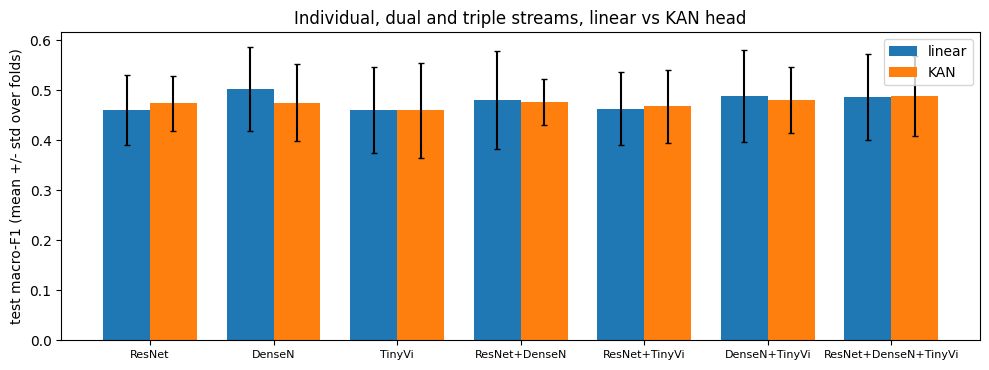

In [49]:
# ablation table and chart
abl = []
for t in TAGS:
    if t in have:
        r = res[res.tag == t]
        c = next(c for c in CONFIGS if c["tag"] == t)
        abl.append(dict(streams="+".join(PRETTY[ch] for ch in c["streams"]), n_streams=len(c["streams"]),
                        fusion="gated" if c["gated"] else "concat", classifier=c["head"].upper() if c["head"] == "kan" else "linear",
                        macro_F1=ms(r.macro_f1), pooled_macro_F1=round(pool.loc[t, "macro_f1"], 4)))
display(pd.DataFrame(abl))

fig, ax = plt.subplots(figsize=(10, 3.8))
combos = ["R", "D", "T", "RD", "RT", "DT", "RDT"]
w = 0.38
for k, head in enumerate(["linear", "kan"]):
    means, stds = [], []
    for s in combos:
        t = (f"{s}_{head}" if len(s) == 1 else f"H_{s}_{head}")
        r = res[res.tag == t].macro_f1
        means.append(r.mean() if len(r) else np.nan); stds.append(r.std(ddof=1) if len(r) > 1 else 0)
    ax.bar(np.arange(len(combos)) + (k - .5) * w, means, w, yerr=stds, capsize=2, label=head.upper() if head == "kan" else "linear")
ax.set_xticks(range(len(combos))); ax.set_xticklabels(["+".join(PRETTY[c][:6] for c in s) for s in combos], fontsize=8)
ax.set_ylabel("test macro-F1 (mean +/- std over folds)"); ax.legend(); ax.set_title("Individual, dual and triple streams, linear vs KAN head")
fig.tight_layout(); fig.savefig(OUT / "ablation_bar.png", dpi=120); plt.show()

,Corrosion,Crack,Dent,Missing Head,Paint Off,Scratch
ResNet50,0.231,0.663,0.543,0.580,0.411,0.459
DenseNet121,0.358,0.693,0.589,0.617,0.416,0.491
TinyViT-5M,0.135,0.692,0.559,0.626,0.412,0.440
Hybrid-RDT,0.250,0.682,0.575,0.602,0.425,0.495
Hybrid-RDT + KAN,0.328,0.643,0.572,0.610,0.426,0.500


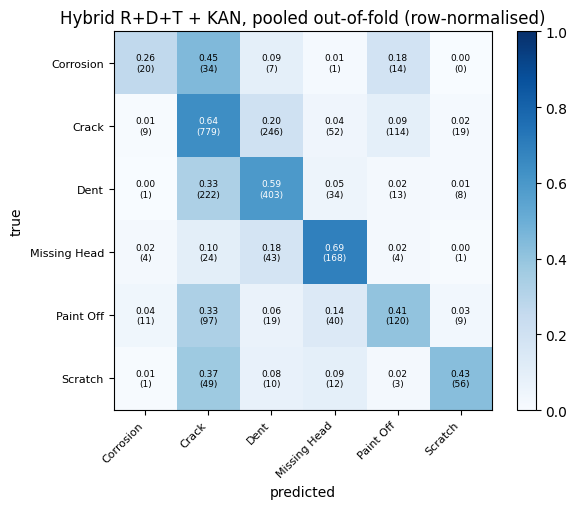

In [50]:
# per-class results and confusion matrix
show = [t for t in ["R_linear", "D_linear", "T_linear", "H_RDT_linear", "H_RDT_kan"] if t in pool.index]
if show:
    pc = pool.loc[show, [f"f1_{c}" for c in classes]].copy()
    pc.columns = classes; pc.index = [pretty(t) for t in pc.index]
    display(pc.round(3))

if "H_RDT_kan" in pooled:
    p = pooled["H_RDT_kan"]
    cm = np.array(A.compute_metrics(p.y_true.values, p.y_pred.values, classes)["confusion"], dtype=float)
    cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes, fontsize=8)
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, f"{cmn[i, j]:.2f}\n({int(cm[i, j])})", ha="center", va="center", fontsize=6.5,
                    color="white" if cmn[i, j] > .5 else "black")
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Hybrid R+D+T + KAN, pooled out-of-fold (row-normalised)")
    fig.colorbar(im, fraction=.046); fig.tight_layout(); fig.savefig(OUT / "confusion_H_RDT_kan.png", dpi=120); plt.show()

In [51]:
# gate weights and cost
g = []
for f in sorted(OUT.glob("H_RDT_kan_fold*.json")):
    r = json.load(open(f)); g.append(r["gates"])
if g:
    print("Learned stream weights (ResNet50, DenseNet121, TinyViT-5M), mean over folds:", np.round(np.mean(g, 0), 3))

eff = res[res.tag.isin(TAGS)].groupby("tag").agg(params_M=("params_total_M", "first"), trainable_head_M=("params_trainable_M", "first"),
                                                 GFLOPs=("gflops", "first"), inference_ms_bs1=("inference_ms", "mean"),
                                                 head_train_s_per_fold=("train_seconds", "mean"))
eff = eff.reindex([t for t in TAGS if t in eff.index]); eff.index = [pretty(t) for t in eff.index]
print("\nPipeline cost = backbones (frozen) + head; FLOPs = 2 x multiply-adds at 224x224 (head FLOPs are negligible and not added):")
display(eff.round(3)); eff.to_csv(OUT / "efficiency.csv")

Learned stream weights (ResNet50, DenseNet121, TinyViT-5M), mean over folds: [0.304 0.345 0.351]

Pipeline cost = backbones (frozen) + head; FLOPs = 2 x multiply-adds at 224x224 (head FLOPs are negligible and not added):


,params_M,trainable_head_M,GFLOPs,inference_ms_bs1,head_train_s_per_fold
ResNet50,25.619,2.110,8.174,7.552,8.478
ResNet50 + KAN,27.978,4.470,8.174,10.121,15.702
DenseNet121,7.485,0.531,5.666,19.309,4.907
DenseNet121 + KAN,8.799,1.845,5.666,21.544,14.855
TinyViT-5M,5.125,0.053,2.510,9.977,4.845
TinyViT-5M + KAN,5.720,0.648,2.510,12.264,14.141
Hybrid-RD,35.200,4.739,13.841,26.396,7.540
Hybrid-RD + KAN,38.605,8.143,13.841,28.517,17.829
Hybrid-RT,31.399,2.819,10.684,16.998,6.512
Hybrid-RT + KAN,34.085,5.505,10.684,19.543,16.666


In [53]:
# setup for the baselines
import os, sys, json, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

MODELS = ["resnet50", "densenet121", "tinyvit5m"]
BASE_FOLDS = [0, 1, 2, 3, 4]
EPOCHS = 10
SAVE_CKPT = True

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT = Path("/content/drive/MyDrive/AircraftDefectDetection")
    get_ipython().run_line_magic("pip", "install -q timm")
    DATA_DIR = Path("/content/Aircraft_Defect_Image_Dataset")
    if not DATA_DIR.exists():
        tmp = Path("/content/_unzip"); tmp.mkdir(exist_ok=True)
        with zipfile.ZipFile(PROJECT / "Aircraft_Defect_Image_Dataset.zip") as z:
            z.extractall(tmp)
        DATA_DIR = next(p.parent for p in tmp.rglob("train") if p.is_dir())
    CACHE_DIR = Path("/content/cache")
else:
    cwd = Path.cwd()
    PROJECT = cwd.parent if cwd.name == "notebooks" else cwd
    DATA_DIR = PROJECT / "Aircraft_Defect_Image_Dataset"
    CACHE_DIR = PROJECT / "outputs" / "cache"


SPLITS = PROJECT / "splits"
OUT = PROJECT / "outputs" / ("baselines_debug" if DEBUG else "baselines")
CKPT = PROJECT / "checkpoints" / ("baselines_debug" if DEBUG else "baselines")
OUT.mkdir(parents=True, exist_ok=True)

cfg = dict(A.DEFAULT_CFG)
cfg["num_workers"] = 2 if IN_COLAB else 0
cfg["epochs"] = EPOCHS
if DEBUG:
    cfg.update(epochs=1, batch_size=8, debug_n=24)
    BASE_FOLDS = [0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "(no GPU - on Colab: Runtime > Change runtime type > GPU)")
print("torch", torch.__version__, "| timm", timm.__version__)
print("DEBUG:", DEBUG, "| models:", MODELS, "| folds:", BASE_FOLDS)
print("output:", OUT)
if not DEBUG and device.type != "cuda":
    print("WARNING: real training on CPU will be extremely slow.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda Tesla T4
torch 2.11.0+cu128 | timm 1.0.29
DEBUG: False | models: ['resnet50', 'densenet121', 'tinyvit5m'] | folds: [0, 1, 2]
output: /content/drive/MyDrive/AircraftDefectDetection/outputs/baselines


In [54]:
# load data and image cache
df, split_cfg = A.load_splits(SPLITS)
classes = split_cfg["classes"]
print("images:", len(df), "| classes:", classes)
print("groups:", split_cfg["n_groups"], "| folds:", split_cfg["n_folds"])

images = A.build_image_cache(df, DATA_DIR, CACHE_DIR)
print("image cache:", images.shape, images.dtype, f"{images.nbytes / 1e6:.0f} MB")

with open(OUT / "env.json", "w") as fh:
    json.dump(dict(torch=torch.__version__, timm=timm.__version__, device=str(device), cfg=cfg, models=A.BACKBONES), fh, indent=2)

images: 2647 | classes: ['Corrosion', 'Crack', 'Dent', 'Missing Head', 'Paint Off', 'Scratch']
groups: 652 | folds: 5
image cache: (2647, 224, 224, 3) uint8 398 MB


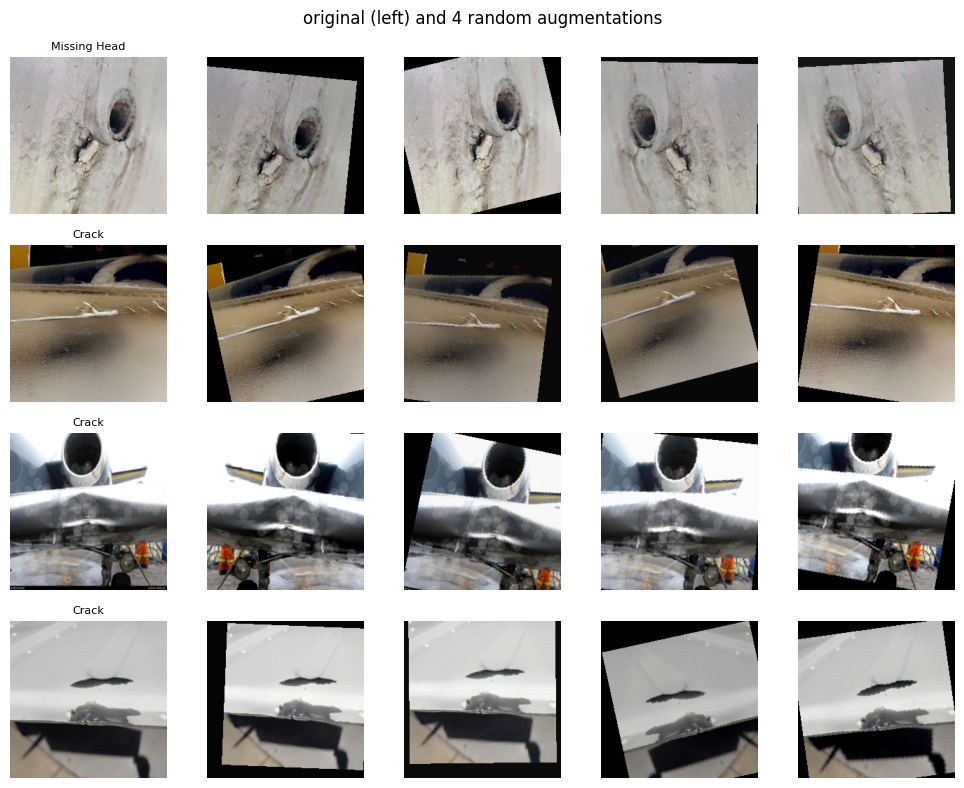

In [55]:
# augmentation preview
rng = np.random.RandomState(0)
aug = A.make_transforms(train=True)
mean = torch.tensor(A.IMAGENET_MEAN)[:, None, None]; std = torch.tensor(A.IMAGENET_STD)[:, None, None]
pick = rng.choice(len(df), 4, replace=False)
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
for r, i in enumerate(pick):
    base = torch.from_numpy(images[i]).permute(2, 0, 1).contiguous()
    axes[r, 0].imshow(images[i]); axes[r, 0].set_title(df.label[i], fontsize=8)
    for c in range(1, 5):
        x = aug(base) * std + mean
        axes[r, c].imshow(x.clamp(0, 1).permute(1, 2, 0).numpy())
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle("original (left) and 4 random augmentations"); fig.tight_layout()
fig.savefig(PROJECT / "outputs" / "augmentation_preview.png", dpi=100); plt.show()

In [56]:
# train the baselines
for key in MODELS:
    for fold in BASE_FOLDS:
        if (OUT / f"{key}_fold{fold}.json").exists():
            print(f"skip {key} fold {fold} (done)")
            continue
        A.train_fold(
            build_model=lambda key=key: A.SingleModel(key, len(classes), dropout=cfg["head_dropout"]),
            tag=key, df=df, images=images, fold=fold, classes=classes, cfg=cfg, device=device,
            out_dir=OUT, ckpt_dir=CKPT if SAVE_CKPT and not DEBUG else None)

[resnet50 fold 0] train 1826 | val 292 | test 529
  ep 01 | train 0.9727 | val loss 1.1935 | val acc 0.5068 | val macro-F1 0.3071
  ep 02 | train 0.6834 | val loss 1.1442 | val acc 0.5377 | val macro-F1 0.4303
  ep 03 | train 0.6280 | val loss 1.1963 | val acc 0.5342 | val macro-F1 0.4027
  ep 04 | train 0.5869 | val loss 1.3030 | val acc 0.5753 | val macro-F1 0.4180
  ep 05 | train 0.5639 | val loss 1.2525 | val acc 0.5479 | val macro-F1 0.3923
  ep 06 | train 0.5578 | val loss 1.1222 | val acc 0.5856 | val macro-F1 0.3471
  ep 07 | train 0.5334 | val loss 1.0726 | val acc 0.5548 | val macro-F1 0.3687
  ep 08 | train 0.5169 | val loss 1.0682 | val acc 0.5719 | val macro-F1 0.4274
  ep 09 | train 0.5141 | val loss 1.0085 | val acc 0.6336 | val macro-F1 0.4068
  ep 10 | train 0.5037 | val loss 1.1139 | val acc 0.5514 | val macro-F1 0.4246
  TEST | acc 0.6749 | macro-F1 0.5139 (best epoch 2)
[resnet50 fold 1] train 1822 | val 297 | test 528
  ep 01 | train 0.9853 | val loss 1.5810 | val 

In [57]:
# baseline results
res = A.collect_results(OUT, MODELS)
display(res.round(4))

if len(res):
    def ms(s):
        return f"{s.mean():.4f} +/- {s.std(ddof=1):.4f}" if len(s) > 1 else f"{s.mean():.4f}"
    agg = res.groupby("tag").agg(folds=("fold", "count"), accuracy=("accuracy", ms), macro_f1=("macro_f1", ms),
                                 macro_precision=("macro_precision", ms), macro_recall=("macro_recall", ms))
    print("\nTest results, mean +/- std over folds (sample std):")
    display(agg)
    eff = res.groupby("tag").agg(params_M=("params_total_M", "first"), gflops=("gflops", "first"),
                                 inference_ms_bs1=("inference_ms", "mean"), train_seconds_per_fold=("train_seconds", "mean"))
    print("Efficiency (FLOPs = 2 x multiply-adds, 224x224, batch 1):")
    display(eff.round(3))

,tag,fold,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,best_epoch,train_seconds,params_total_M,params_trainable_M,gflops,inference_ms
0,densenet121,0,0.5652,0.4120,0.4067,0.4072,0.5555,10,121.2090,6.9621,6.5842,5.6663,17.9667
1,densenet121,1,0.5436,0.3931,0.3952,0.3850,0.5201,8,118.0450,6.9621,6.5842,5.6663,16.9328
2,densenet121,2,0.6478,0.6370,0.5397,0.5657,0.6424,6,117.2856,6.9621,6.5842,5.6663,17.2837
3,resnet50,0,0.6749,0.5745,0.4846,0.5139,0.6593,2,120.5854,23.5244,23.2991,8.1743,9.1466
4,resnet50,1,0.5606,0.4055,0.3840,0.3795,0.5341,4,95.4782,23.5244,23.2991,8.1743,6.8192
5,resnet50,2,0.5970,0.6262,0.4822,0.5102,0.5860,8,94.9312,23.5244,23.2991,8.1743,9.5714
6,tinyvit5m,0,0.5066,0.3789,0.3900,0.3693,0.5006,6,109.3159,5.0743,4.9824,2.5097,14.1534
7,tinyvit5m,1,0.5720,0.4463,0.4297,0.4148,0.5563,8,100.5571,5.0743,4.9824,2.5097,9.9224
8,tinyvit5m,2,0.6196,0.5724,0.5898,0.5406,0.6026,10,101.9228,5.0743,4.9824,2.5097,9.9338



Test results, mean +/- std over folds (sample std):


,folds,accuracy,macro_f1,macro_precision,macro_recall
tag,,,,,
densenet121,3,0.5855 +/- 0.0550,0.4526 +/- 0.0985,0.4807 +/- 0.1357,0.4472 +/- 0.0803
resnet50,3,0.6108 +/- 0.0584,0.4678 +/- 0.0766,0.5354 +/- 0.1154,0.4503 +/- 0.0574
tinyvit5m,3,0.5661 +/- 0.0567,0.4416 +/- 0.0888,0.4659 +/- 0.0982,0.4698 +/- 0.1057


Efficiency (FLOPs = 2 x multiply-adds, 224x224, batch 1):


,params_M,gflops,inference_ms_bs1,train_seconds_per_fold
tag,,,,
densenet121,6.962,5.666,17.394,118.847
resnet50,23.524,8.174,8.512,103.665
tinyvit5m,5.074,2.510,11.337,103.932


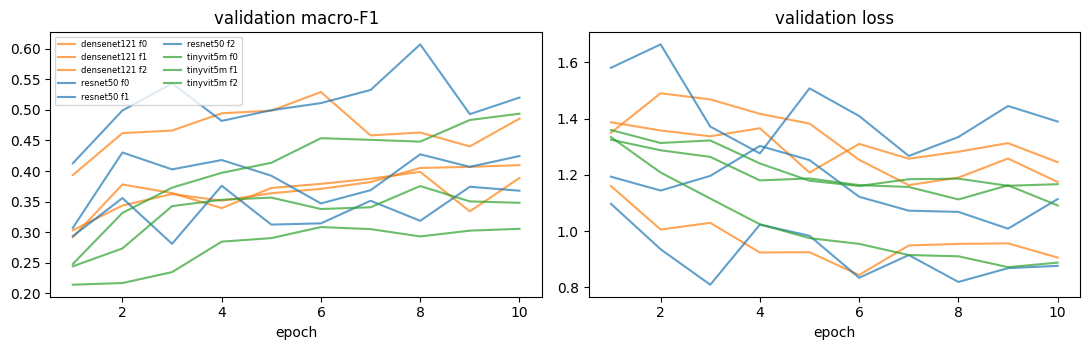

In [58]:
# learning curves
files = sorted(OUT.glob("*_fold*.json"))
if files:
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    colors = {"resnet50": "tab:blue", "densenet121": "tab:orange", "tinyvit5m": "tab:green"}
    for f in files:
        r = json.load(open(f)); h = pd.DataFrame(r["history"])
        ax[0].plot(h.epoch, h.val_macro_f1, color=colors.get(r["tag"]), alpha=.7, label=f"{r['tag']} f{r['fold']}")
        ax[1].plot(h.epoch, h.val_loss, color=colors.get(r["tag"]), alpha=.7)
    ax[0].set_title("validation macro-F1"); ax[1].set_title("validation loss")
    for a in ax:
        a.set_xlabel("epoch")
    ax[0].legend(fontsize=6, ncol=2); fig.tight_layout()
    fig.savefig(OUT / "learning_curves.png", dpi=110); plt.show()

In [59]:
# per-class f1 of the baselines
rows = []
for f in sorted(OUT.glob("*_fold*.json")):
    r = json.load(open(f))
    if r["tag"] in MODELS:
        for c, m in r["test"]["per_class"].items():
            rows.append(dict(model=r["tag"], fold=r["fold"], cls=c, f1=m["f1"], recall=m["recall"], support=m["support"]))
if rows:
    pc = pd.DataFrame(rows)
    display(pc.pivot_table(index="model", columns="cls", values="f1", aggfunc="mean").round(3))

cls,Corrosion,Crack,Dent,Missing Head,Paint Off,Scratch
model,,,,,,
densenet121,0.156,0.650,0.548,0.758,0.433,0.171
resnet50,0.167,0.679,0.579,0.720,0.426,0.238
tinyvit5m,0.264,0.646,0.539,0.593,0.369,0.239


In [ ]:
# final comparison: fine-tuned baselines vs frozen-feature models (same folds, same test images)
H_OUT = PROJECT / "outputs" / ("hybrids_debug" if DEBUG else "hybrids")
B_OUT = PROJECT / "outputs" / ("baselines_debug" if DEBUG else "baselines")
fus = A.collect_results(H_OUT, TAGS)
bas = A.collect_results(B_OUT, MODELS)

def ms2(s):
    return f"{s.mean():.4f} +/- {s.std(ddof=1):.4f}" if len(s) > 1 else f"{s.mean():.4f}"

if len(fus) and len(bas):
    common = sorted(set(fus.fold) & set(bas.fold))
    fus, bas = fus[fus.fold.isin(common)], bas[bas.fold.isin(common)]
    print("folds compared:", common)

    BASE_LABEL = {KEY[k]: PRETTY[k] + " (fine-tuned)" for k in KEY}
    FROZEN = ["R_linear", "D_linear", "T_linear", "H_RDT_linear", "H_RDT_kan"]
    rows = [(BASE_LABEL[m], m, bas) for m in MODELS] + [(pretty(t) + " (frozen)", t, fus) for t in FROZEN]

    summ, per_fold = [], {}
    for name, t, d in rows:
        r = d[d.tag == t].sort_values("fold")
        if r.empty:
            continue
        per_fold[name] = r.set_index("fold").macro_f1
        summ.append(dict(model=name, folds=len(r), accuracy=ms2(r.accuracy), macro_f1=ms2(r.macro_f1),
                         params_M=round(r.params_total_M.iloc[0], 1), GFLOPs=round(r.gflops.astype(float).iloc[0], 2),
                         inference_ms_bs1=round(r.inference_ms.mean(), 1)))
    print("Test results, mean +/- std over folds (params/GFLOPs include the frozen backbones):")
    display(pd.DataFrame(summ).set_index("model"))

    pf = pd.DataFrame(per_fold)
    print("\nMacro-F1 per fold:")
    display(pf.T.round(3))

    pairs = []
    for h in [pretty(t) + " (frozen)" for t in ["H_RDT_linear", "H_RDT_kan"]]:
        for b in BASE_LABEL.values():
            if h in pf and b in pf:
                d = (pf[h] - pf[b]).dropna()
                pairs.append(dict(hybrid=h, baseline=b, folds=len(d), mean_diff_macro_f1=round(d.mean(), 4),
                                  hybrid_better_on=f"{int((d > 0).sum())}/{len(d)}"))
    print("\nPaired per-fold comparison (hybrid minus baseline, macro-F1):")
    display(pd.DataFrame(pairs))
else:
    print("run Parts A and B first")

In [ ]:
# confusion matrices (pooled out-of-fold): 1) individual fine-tuned models, 2) linear head, 3) KAN head
NL = chr(10)
H_OUT = PROJECT / "outputs" / ("hybrids_debug" if DEBUG else "hybrids")
B_OUT = PROJECT / "outputs" / ("baselines_debug" if DEBUG else "baselines")

def pooled_cm(out_dir, tag):
    files = sorted(Path(out_dir).glob(f"preds_{tag}_fold*.csv"))
    if not files:
        return None
    p = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    m = A.compute_metrics(p.y_true.values, p.y_pred.values, classes)
    return np.array(m["confusion"], dtype=float), len(files), m["macro_f1"], m["accuracy"]

def cm_figure(items, title, fname, ncols=3):
    """Compact grid: 3 panels per row, text large enough to stay readable when the figure is scaled to a page width."""
    nrows = -(-len(items) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols + 0.6, 3.55 * nrows + 0.5), squeeze=False, constrained_layout=True)
    im, nf = None, 0
    for ax, (name, d, tag) in zip(axes.ravel(), items):
        r = pooled_cm(d, tag)
        if r is None:
            ax.axis("off"); continue
        cm, nf, f1, acc = r
        cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
        im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=8.5)
        ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes, fontsize=8.5)
        for i in range(len(classes)):
            for j in range(len(classes)):
                ax.text(j, i, f"{cmn[i, j]:.2f}" + NL + f"{int(cm[i, j])}", ha="center", va="center", fontsize=8,
                        color="white" if cmn[i, j] > .5 else "black")
        ax.set_title(f"{name}{NL}macro-F1 {f1:.3f} | acc {acc:.3f}", fontsize=9.5)
        ax.set_xlabel("predicted", fontsize=9); ax.set_ylabel("true", fontsize=9)
    for ax in axes.ravel()[len(items):]:
        ax.axis("off")
    if im is not None:
        fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02, label="share of the true class")
    fig.suptitle(title + NL + "(top: share of the true class, bottom: number of images; " + str(nf) + " folds pooled)", fontsize=10.5)
    fig.savefig(H_OUT / fname, dpi=150); plt.show()

COMBOS = ["R", "D", "T", "RD", "RT", "DT", "RDT"]
def tag_of(s, head):
    return f"{s}_{head}" if len(s) == 1 else f"H_{s}_{head}"
def label_of(s):
    return " + ".join(PRETTY[ch] for ch in s)

# 1) individual fine-tuned models (end-to-end baselines)
cm_figure([(PRETTY[k] + " (fine-tuned)", B_OUT, KEY[k]) for k in "RDT"],
          "Individual fine-tuned models", "confusion_1_individual_finetuned.png")

# 2) frozen features, linear head (no KAN): single streams, pairs, triple
cm_figure([(label_of(s), H_OUT, tag_of(s, "linear")) for s in COMBOS],
          "Frozen features, linear head (no KAN)", "confusion_2_linear_head.png")

# 3) frozen features, KAN head: single streams, pairs, triple, and triple without gating
kan = [(label_of(s) + " + KAN", H_OUT, tag_of(s, "kan")) for s in COMBOS]
kan.append(("R + D + T + KAN (concat, no gate)", H_OUT, "H_RDT_kan_concat"))
cm_figure(kan, "Frozen features, KAN head", "confusion_3_kan_head.png")

In [ ]:
# gate weights per fold (Hybrid R+D+T, gated fusion)
H_OUT = PROJECT / "outputs" / ("hybrids_debug" if DEBUG else "hybrids")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
gate_rows = []
for ax, head in zip(axes, ["linear", "kan"]):
    g = {}
    for f in sorted(H_OUT.glob(f"H_RDT_{head}_fold?.json")):
        r = json.load(open(f))
        g[r["fold"]] = r["gates"]
    if not g:
        ax.axis("off")
        continue
    folds = sorted(g)
    arr = np.array([g[k] for k in folds])
    w = 0.26
    for s, ch in enumerate("RDT"):
        ax.bar(np.arange(len(folds)) + (s - 1) * w, arr[:, s], w, label=PRETTY[ch])
        for k, v in zip(folds, arr[:, s]):
            gate_rows.append(dict(head=head.upper() if head == "kan" else "linear", fold=k, stream=PRETTY[ch], gate=round(v, 3)))
    ax.axhline(1 / 3, ls="--", color="grey", lw=1)
    ax.set_xticks(range(len(folds))); ax.set_xticklabels([f"fold {k}" for k in folds])
    ax.set_title("Hybrid R+D+T + " + ("KAN" if head == "kan" else "linear") + " head")
axes[0].set_ylabel("learned stream weight (dashed = equal 1/3)")
axes[0].legend(fontsize=8)
fig.tight_layout(); fig.savefig(H_OUT / "gate_weights_per_fold.png", dpi=120); plt.show()
if gate_rows:
    display(pd.DataFrame(gate_rows).pivot_table(index=["head", "fold"], columns="stream", values="gate")[[PRETTY[c] for c in "RDT"]])

In [ ]:
# best epoch and training time (per model, over folds)
H_OUT = PROJECT / "outputs" / ("hybrids_debug" if DEBUG else "hybrids")
B_OUT = PROJECT / "outputs" / ("baselines_debug" if DEBUG else "baselines")
hyb = A.collect_results(H_OUT, TAGS)
fin = A.collect_results(B_OUT, MODELS)

def epoch_table(d, tags, namer, budget):
    rows = []
    for t in tags:
        r = d[d.tag == t]
        if r.empty:
            continue
        rows.append(dict(model=namer(t), folds=len(r), epoch_budget=budget,
                         best_epoch_mean=round(r.best_epoch.mean(), 1),
                         best_epoch_min_max=f"{int(r.best_epoch.min())}-{int(r.best_epoch.max())}",
                         train_s_per_fold=round(r.train_seconds.mean(), 1)))
    return pd.DataFrame(rows).set_index("model")

t_fin = epoch_table(fin, MODELS, lambda t: PRETTY[{v: k for k, v in KEY.items()}[t]] + " (fine-tuned)", 10)
t_hyb = epoch_table(hyb, TAGS, lambda t: pretty(t) + " (frozen)", cfg["head_epochs"])
print("Best epoch is chosen by validation macro-F1. Frozen-feature times cover the head only (backbone feature extraction is done once and not included).")
display(pd.concat([t_fin, t_hyb]))

In [ ]:
# train vs validation loss gap (overfitting check)
# note: train loss is measured with augmentation/dropout on and validation loss with them off, so the gap is only comparable between models trained the same way
H_OUT = PROJECT / "outputs" / ("hybrids_debug" if DEBUG else "hybrids")
B_OUT = PROJECT / "outputs" / ("baselines_debug" if DEBUG else "baselines")

def histories(out_dir, tag):
    out = []
    for f in sorted(Path(out_dir).glob(f"{tag}_fold?.json")):
        r = json.load(open(f))
        out.append((r["fold"], pd.DataFrame(r["history"]), r["best_epoch"]))
    return out

groups = [(PRETTY[k] + " (fine-tuned)", B_OUT, KEY[k]) for k in "RDT"]
groups += [(pretty(t) + " (frozen)", H_OUT, t) for t in ["H_RDT_linear", "H_RDT_kan"]]

fig, axes = plt.subplots(1, len(groups), figsize=(4.2 * len(groups), 3.6), sharey=False)
gap_rows = []
for ax, (name, d, tag) in zip(np.atleast_1d(axes), groups):
    hs = histories(d, tag)
    if not hs:
        ax.axis("off")
        continue
    n = min(len(h) for _, h, _ in hs)
    tr = np.mean([h.train_loss.values[:n] for _, h, _ in hs], axis=0)
    va = np.mean([h.val_loss.values[:n] for _, h, _ in hs], axis=0)
    ep = np.arange(1, n + 1)
    ax.plot(ep, tr, label="train"); ax.plot(ep, va, label="validation")
    ax.set_title(name, fontsize=9); ax.set_xlabel("epoch"); ax.set_ylabel("loss (mean over folds)")
    ax.legend(fontsize=7)
    at_best = [h.val_loss[h.epoch == be].iloc[0] - h.train_loss[h.epoch == be].iloc[0] for _, h, be in hs]
    at_last = [h.val_loss.iloc[-1] - h.train_loss.iloc[-1] for _, h, _ in hs]
    gap_rows.append(dict(model=name, folds=len(hs), gap_at_best_epoch=round(float(np.mean(at_best)), 3),
                         gap_at_last_epoch=round(float(np.mean(at_last)), 3),
                         final_train_loss=round(float(tr[-1]), 3), final_val_loss=round(float(va[-1]), 3)))
fig.tight_layout(); fig.savefig(H_OUT / "train_val_loss_gap.png", dpi=120); plt.show()
print("gap = validation loss - training loss (larger = more overfitting)")
display(pd.DataFrame(gap_rows).set_index("model"))

In [ ]:
# class support: how imbalanced is the data
sup = df.label.value_counts().reindex(classes)
tab = pd.DataFrame({"images": sup, "share_%": (100 * sup / sup.sum()).round(1)})
tab["x_smaller_than_largest"] = (sup.max() / sup).round(1)
tab.insert(1, "independent_photos", df.groupby("label").group.nunique().reindex(classes))
for k in range(split_cfg["n_folds"]):
    tab[f"test_fold{k}"] = df[df[f"role_f{k}"] == "test"].label.value_counts().reindex(classes).fillna(0).astype(int)
tab.loc["total"] = [int(sup.sum()), int(df.group.nunique()), 100.0, np.nan] + [int((df[f"role_f{k}"] == "test").sum()) for k in range(split_cfg["n_folds"])]
count_cols = [col for col in tab.columns if col not in ("share_%", "x_smaller_than_largest")]
tab[count_cols] = tab[count_cols].astype("Int64")
display(tab)
print(f"majority class: {sup.idxmax()} ({100 * sup.max() / sup.sum():.1f}% of images), so always predicting it gives accuracy {sup.max() / sup.sum():.3f} and macro-F1 near {2 * (sup.max() / sup.sum()) / (1 + sup.max() / sup.sum()) / len(classes):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
x = np.arange(len(classes)); w = 0.38
imgs = tab.loc[classes, "images"].values
grps = tab.loc[classes, "independent_photos"].values
a = axes[0]
b1 = a.bar(x - w / 2, imgs, w, label="images (incl. augmented copies)", color="tab:blue")
b2 = a.bar(x + w / 2, grps, w, label="independent photos (groups)", color="tab:orange")
for bars in (b1, b2):
    for r in bars:
        a.text(r.get_x() + r.get_width() / 2, r.get_height(), str(int(r.get_height())), ha="center", va="bottom", fontsize=8)
a.set_xticks(x); a.set_xticklabels(classes, rotation=30, ha="right", fontsize=8)
a.set_ylabel("count"); a.set_title("Images and independent photos per class (whole dataset)"); a.legend(fontsize=8)

a = axes[1]
nf = split_cfg["n_folds"]; w2 = 0.8 / nf
for k in range(nf):
    a.bar(x + (k - (nf - 1) / 2) * w2, tab.loc[classes, f"test_fold{k}"].values, w2, label=f"fold {k}")
a.set_xticks(x); a.set_xticklabels(classes, rotation=30, ha="right", fontsize=8)
a.set_ylabel("test images"); a.set_title("Test images per class in each fold"); a.legend(fontsize=8, ncol=nf)
fig.tight_layout()
fig.savefig(PROJECT / "outputs" / "class_support.png", dpi=120); plt.show()

In [ ]:
# fold structure: how every fold is split into train / validation / test
nf = split_cfg["n_folds"]
sizes = pd.DataFrame({f"fold {k}": df[f"role_f{k}"].value_counts() for k in range(nf)}).reindex(["train", "val", "test"]).T
test_share = pd.DataFrame({f"fold {k}": df[df[f"role_f{k}"] == "test"].label.value_counts(normalize=True).mul(100) for k in range(nf)}).reindex(classes).T
test_groups = pd.DataFrame({f"fold {k}": df[df[f"role_f{k}"] == "test"].groupby("label").group.nunique() for k in range(nf)}).reindex(classes)
print("images per role in each fold:")
display(sizes)
print("independent photos (groups) of each class in each fold's test set:")
display(test_groups)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
sizes.plot.bar(stacked=True, ax=axes[0], color=["tab:blue", "tab:orange", "tab:green"], rot=0)
for cont, col in zip(axes[0].containers, sizes.columns):
    axes[0].bar_label(cont, labels=[str(int(v)) for v in sizes[col]], label_type="center", fontsize=7, color="white")
axes[0].set_title("Images per role in each fold"); axes[0].set_ylabel("images")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=8)

test_share.plot.bar(stacked=True, ax=axes[1], rot=0, colormap="tab20")
axes[1].set_title("Class mix of each fold's test set (%)"); axes[1].set_ylabel("% of test images")
axes[1].legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)

x = np.arange(len(classes)); w = 0.8 / nf
for k in range(nf):
    axes[2].bar(x + (k - (nf - 1) / 2) * w, test_groups[f"fold {k}"].values, w, label=f"fold {k}")
axes[2].set_xticks(x); axes[2].set_xticklabels(classes, rotation=30, ha="right", fontsize=8)
axes[2].set_ylabel("independent photos"); axes[2].set_title("Independent photos per class in each test fold")
axes[2].legend(fontsize=7, ncol=nf, loc="upper center", bbox_to_anchor=(0.5, -0.28))
fig.tight_layout(); fig.savefig(PROJECT / "outputs" / "fold_structure.png", dpi=120); plt.show()

In [ ]:
# analysis setup: the models used in the extra comparison analyses below
H_OUT = PROJECT / "outputs" / ("hybrids_debug" if DEBUG else "hybrids")
B_OUT = PROJECT / "outputs" / ("baselines_debug" if DEBUG else "baselines")
MAIN = [(PRETTY[k] + " (fine-tuned)", B_OUT, KEY[k]) for k in "RDT"]
MAIN += [(pretty(t) + " (frozen)", H_OUT, t) for t in ["R_linear", "D_linear", "T_linear", "H_RDT_linear", "H_RDT_kan"]]
group_of = df.set_index("path").group

def load_preds(out_dir, tag):
    files = sorted(Path(out_dir).glob(f"preds_{tag}_fold?.csv"))
    if not files:
        return None
    p = pd.concat([pd.read_csv(f) for f in files], ignore_index=True).sort_values("path").reset_index(drop=True)
    p["group"] = group_of.reindex(p.path).values
    return p

PREDS = {n: load_preds(d, t) for n, d, t in MAIN}
PREDS = {n: p for n, p in PREDS.items() if p is not None}
assert len({tuple(p.path) for p in PREDS.values()}) == 1, "models were not evaluated on the same images: finish all folds first"
print(len(PREDS), "models, each with", len(next(iter(PREDS.values()))), "pooled out-of-fold predictions")

In [ ]:
# macro-F1 of every model in every fold (dots) and its mean (black bar)
allr = pd.concat([A.collect_results(H_OUT, [t for _, d, t in MAIN if d == H_OUT]),
                  A.collect_results(B_OUT, [t for _, d, t in MAIN if d == B_OUT])])
fig, ax = plt.subplots(figsize=(9, 4.6))
for yi, (name, d, t) in enumerate(MAIN):
    r = allr[allr.tag == t].sort_values("fold")
    if r.empty:
        continue
    ax.scatter(r.macro_f1, [yi] * len(r), s=45, alpha=.75)
    for _, row in r.iterrows():
        ax.text(row.macro_f1, yi - 0.2, str(int(row.fold)), fontsize=6, ha="center")
    ax.plot([r.macro_f1.mean()] * 2, [yi - .3, yi + .3], color="black", lw=2)
ax.set_yticks(range(len(MAIN))); ax.set_yticklabels([n for n, _, _ in MAIN], fontsize=8); ax.invert_yaxis()
ax.set_xlabel("test macro-F1 (numbers above dots = fold, black bar = mean over folds)")
ax.set_title("Macro-F1 per fold for every model")
fig.tight_layout(); fig.savefig(H_OUT / "macro_f1_per_fold.png", dpi=120); plt.show()

In [ ]:
# group bootstrap: 95% confidence intervals and paired differences (resampling independent photos, not images)
K = len(classes)
names = list(PREDS)
gid, glist = pd.factorize(PREDS[names[0]].group)
G = len(glist)
M = {}
for n, p in PREDS.items():
    m = np.zeros((G, K, K), np.int32)
    np.add.at(m, (gid, p.y_true.values, p.y_pred.values), 1)
    M[n] = m

def scores_from(cm):
    tp = np.einsum("bkk->bk", cm).astype(float)
    den = 2 * tp + (cm.sum(1) - tp) + (cm.sum(2) - tp)
    f1 = np.where(den > 0, 2 * tp / np.maximum(den, 1), 0).mean(1)
    return f1, tp.sum(1) / cm.sum((1, 2))

B = 5000
rng = np.random.default_rng(0)
f1s = {n: [] for n in names}; accs = {n: [] for n in names}
for _ in range(B // 250):
    idx = rng.integers(0, G, (250, G))
    for n in names:
        f1, acc = scores_from(M[n][idx].sum(1))
        f1s[n].append(f1); accs[n].append(acc)
f1s = {n: np.concatenate(v) for n, v in f1s.items()}
accs = {n: np.concatenate(v) for n, v in accs.items()}

rows = []
for n in names:
    f1_0, acc_0 = scores_from(M[n].sum(0)[None])
    lo, hi = np.percentile(f1s[n], [2.5, 97.5]); alo, ahi = np.percentile(accs[n], [2.5, 97.5])
    rows.append(dict(model=n, macro_F1=round(f1_0[0], 4), F1_95CI=f"[{lo:.3f}, {hi:.3f}]",
                     accuracy=round(acc_0[0], 4), acc_95CI=f"[{alo:.3f}, {ahi:.3f}]"))
print(f"pooled out-of-fold scores with 95% CI ({B} resamples of the {G} independent photos):")
display(pd.DataFrame(rows).set_index("model"))

focus = pretty("H_RDT_kan") + " (frozen)"
prow = []
for n in names:
    if n == focus or focus not in f1s:
        continue
    d = f1s[focus] - f1s[n]
    lo, hi = np.percentile(d, [2.5, 97.5])
    prow.append(dict(hybrid=focus, versus=n, mean_diff_macro_F1=round(d.mean(), 4), diff_95CI=f"[{lo:.3f}, {hi:.3f}]",
                     P_hybrid_better=round(float((d > 0).mean()), 3), CI_excludes_zero="yes" if lo > 0 or hi < 0 else "no"))
print("paired differences (same resamples for both models):")
display(pd.DataFrame(prow).set_index("versus"))

fig, ax = plt.subplots(figsize=(8, 4))
for yi, n in enumerate(names):
    lo, hi = np.percentile(f1s[n], [2.5, 97.5])
    ax.errorbar(scores_from(M[n].sum(0)[None])[0][0], yi, xerr=[[scores_from(M[n].sum(0)[None])[0][0] - lo], [hi - scores_from(M[n].sum(0)[None])[0][0]]], fmt="o", capsize=3)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8); ax.invert_yaxis()
ax.set_xlabel("pooled macro-F1 with 95% bootstrap CI"); ax.set_title("Pooled macro-F1 with 95% bootstrap interval")
fig.tight_layout(); fig.savefig(H_OUT / "macro_f1_bootstrap_ci.png", dpi=120); plt.show()

In [ ]:
# accuracy vs cost: macro-F1 against GFLOPs and latency for every model
allres = pd.concat([A.collect_results(H_OUT, TAGS), A.collect_results(B_OUT, MODELS)])
g = allres.groupby("tag").agg(macro_f1=("macro_f1", "mean"), params_M=("params_total_M", "first"),
                              gflops=("gflops", "first"), ms=("inference_ms", "mean"))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)
for ax, col, xl in zip(axes, ["gflops", "ms"], ["GFLOPs per image (backbones, 224x224)", "latency, batch 1 (ms)"]):
    for t, r in g.iterrows():
        if t in MODELS:
            mk, cl = "s", "tab:red"
        elif t.startswith("H_"):
            mk, cl = "^", "tab:green"
        else:
            mk, cl = "o", "tab:blue"
        ax.scatter(r[col], r.macro_f1, marker=mk, color=cl, s=50)
        ax.annotate(t, (r[col], r.macro_f1), fontsize=6, xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel(xl); ax.grid(alpha=.3)
axes[0].set_ylabel("mean test macro-F1 over folds")
axes[0].scatter([], [], marker="s", color="tab:red", label="fine-tuned single"); axes[0].scatter([], [], marker="o", color="tab:blue", label="frozen single")
axes[0].scatter([], [], marker="^", color="tab:green", label="frozen hybrid"); axes[0].legend(fontsize=8)
fig.suptitle("Accuracy vs cost")
fig.tight_layout(); fig.savefig(H_OUT / "accuracy_vs_cost.png", dpi=120); plt.show()

In [ ]:
# per-class F1 and recall for every model (pooled out-of-fold)
f1_tab, rec_tab = {}, {}
for n, p in PREDS.items():
    m = A.compute_metrics(p.y_true.values, p.y_pred.values, classes)
    f1_tab[n] = [m["per_class"][c]["f1"] for c in classes]
    rec_tab[n] = [m["per_class"][c]["recall"] for c in classes]
f1_tab = pd.DataFrame(f1_tab, index=classes).T
rec_tab = pd.DataFrame(rec_tab, index=classes).T
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for ax, tab, title in zip(axes, [f1_tab, rec_tab], ["per-class F1", "per-class recall"]):
    ax.imshow(tab.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(tab))); ax.set_yticklabels(tab.index, fontsize=8)
    for i in range(tab.shape[0]):
        for j in range(tab.shape[1]):
            ax.text(j, i, f"{tab.values[i, j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if tab.values[i, j] > .55 else "black")
    ax.set_title(title + " (pooled out-of-fold)")
fig.tight_layout(); fig.savefig(H_OUT / "per_class_f1_recall_all_models.png", dpi=120); plt.show()
display(f1_tab.round(3))

In [ ]:
# learning curves of the frozen-feature heads: validation macro-F1 and loss (mean over folds)
def head_curves(tag, col):
    hs = [pd.DataFrame(json.load(open(f))["history"]) for f in sorted(H_OUT.glob(f"{tag}_fold?.json"))]
    if not hs:
        return None
    n = min(len(h) for h in hs)
    return np.mean([h[col].values[:n] for h in hs], axis=0)

combos = ["R", "D", "T", "RD", "RT", "DT", "RDT"]
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for j, head in enumerate(["linear", "kan"]):
    for i, (col, yl) in enumerate([("val_macro_f1", "validation macro-F1"), ("val_loss", "validation loss")]):
        ax = axes[i, j]
        for s in combos:
            tag = f"{s}_{head}" if len(s) == 1 else f"H_{s}_{head}"
            y = head_curves(tag, col)
            if y is not None:
                ax.plot(np.arange(1, len(y) + 1), y, label="+".join(PRETTY[c][:6] for c in s), lw=2 if s == "RDT" else 1)
        ax.set_ylabel(yl); ax.grid(alpha=.3)
        if i == 0:
            ax.set_title("KAN head" if head == "kan" else "linear head")
        if i == 1:
            ax.set_xlabel("epoch")
axes[0, 0].legend(fontsize=7, ncol=2)
fig.suptitle("Frozen-feature heads: validation curves, mean over folds")
fig.tight_layout(); fig.savefig(H_OUT / "head_learning_curves.png", dpi=120); plt.show()

In [ ]:
# ranking quality, calibration, and how much the models agree
from sklearn.metrics import roc_auc_score
K = len(classes)
rows, pred_mat = [], {}
for n, p in PREDS.items():
    prob = p[[f"prob_{c}" for c in classes]].values
    prob = prob / prob.sum(1, keepdims=True)
    y = p.y_true.values
    conf = prob.max(1); correct = prob.argmax(1) == y
    ece = 0.0
    edges = np.linspace(0, 1, 11)
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = (conf > lo) & (conf <= hi)
        if sel.any():
            ece += sel.mean() * abs(correct[sel].mean() - conf[sel].mean())
    rows.append(dict(model=n, macro_AUC_ovr=round(roc_auc_score(y, prob, multi_class="ovr", average="macro", labels=list(range(K))), 3),
                     accuracy=round(correct.mean(), 3), mean_confidence=round(conf.mean(), 3), ECE=round(ece, 3)))
    pred_mat[n] = prob.argmax(1)
print("AUC = one-vs-rest macro ROC-AUC (threshold-free ranking quality). ECE = expected calibration error (lower = confidence matches accuracy).")
display(pd.DataFrame(rows).set_index("model"))

names = list(pred_mat)
agree = np.array([[np.mean(pred_mat[a] == pred_mat[b]) for b in names] for a in names])
y_true = PREDS[names[0]].y_true.values
right = np.array([pred_mat[n] == y_true for n in names])
none_right, all_right = ~right.any(0), right.all(0)
print(f"images every model gets wrong: {int(none_right.sum())} ({100 * none_right.mean():.1f}%), every model gets right: {int(all_right.sum())} ({100 * all_right.mean():.1f}%)")
hard = pd.Series(np.array(classes)[y_true[none_right]]).value_counts().reindex(classes).fillna(0).astype(int)
tot = pd.Series(np.array(classes)[y_true]).value_counts().reindex(classes)
display(pd.DataFrame({"all_models_wrong": hard, "class_total": tot, "share_%": (100 * hard / tot).round(1)}))

fig, ax = plt.subplots(figsize=(7, 5.6))
ax.imshow(agree, cmap="Blues", vmin=agree.min(), vmax=1)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=7)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{agree[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if agree[i, j] > (agree.min() + 1) / 2 else "black")
ax.set_title("Share of images on which two models predict the same class")
fig.tight_layout(); fig.savefig(H_OUT / "model_agreement.png", dpi=120); plt.show()

In [ ]:
# trivial baseline: always predict the most frequent training class, and how the models compare with it
nf = split_cfg["n_folds"]
rows, maj_map = [], {}
for k in range(nf):
    role = df[f"role_f{k}"]
    major = df[role == "train"].label_id.value_counts().idxmax()
    te = df[role == "test"]
    m = A.compute_metrics(te.label_id.values, np.full(len(te), major), classes)
    rows.append(dict(fold=k, predicts=classes[major], accuracy=m["accuracy"], macro_f1=m["macro_f1"]))
    maj_map.update({p: major for p in te.path})
maj = pd.DataFrame(rows).set_index("fold")
print("majority-class baseline per fold (predicts the most frequent training class for every test image):")
display(maj.round(4))

fold_scores = {"Majority class (baseline)": maj[["accuracy", "macro_f1"]]}
for name, d, t in MAIN:
    r = A.collect_results(d, [t]).sort_values("fold")
    fold_scores[name] = r.set_index("fold")[["accuracy", "macro_f1"]]

def pm(s):
    return f"{s.mean():.3f} +/- {s.std(ddof=1):.3f}" if len(s) > 1 else f"{s.mean():.3f}"

tab = []
for name, sc_ in fold_scores.items():
    diff = sc_.macro_f1 - maj.macro_f1
    tab.append(dict(model=name, accuracy=pm(sc_.accuracy), macro_F1=pm(sc_.macro_f1),
                    macro_F1_gain_over_baseline=round(diff.mean(), 3),
                    folds_better_than_baseline="-" if name.startswith("Majority") else f"{int((diff > 0).sum())}/{len(diff)}"))
print("test results over the folds, and the gain in macro-F1 over the baseline:")
display(pd.DataFrame(tab).set_index("model"))

# pooled out-of-fold scores with a group bootstrap, paired with the baseline
ref = next(iter(PREDS.values()))
K = len(classes)
gid, glist = pd.factorize(ref.group)
G = len(glist)
y_true = ref.y_true.values

def by_group(pred):
    m = np.zeros((G, K, K), np.int32)
    np.add.at(m, (gid, y_true, pred), 1)
    return m

MB = {"Majority class (baseline)": by_group(ref.path.map(maj_map).values.astype(int))}
MB.update({n: by_group(p.y_pred.values) for n, p in PREDS.items()})

def bscore(cm):
    tp = np.einsum("bkk->bk", cm).astype(float)
    den = 2 * tp + (cm.sum(1) - tp) + (cm.sum(2) - tp)
    return np.where(den > 0, 2 * tp / np.maximum(den, 1), 0).mean(1), tp.sum(1) / cm.sum((1, 2))

rng = np.random.default_rng(2)
BS = {n: [] for n in MB}
for _ in range(5000 // 250):
    idx = rng.integers(0, G, (250, G))
    for n in MB:
        BS[n].append(bscore(MB[n][idx].sum(1))[0])
BS = {n: np.concatenate(v) for n, v in BS.items()}
b0 = "Majority class (baseline)"
prow = []
for n in MB:
    pt = bscore(MB[n].sum(0)[None])
    lo, hi = np.percentile(BS[n], [2.5, 97.5])
    row = dict(model=n, pooled_accuracy=round(pt[1][0], 3), pooled_macro_F1=round(pt[0][0], 3), F1_95CI=f"[{lo:.3f}, {hi:.3f}]")
    if n != b0:
        d = BS[n] - BS[b0]
        dlo, dhi = np.percentile(d, [2.5, 97.5])
        row.update(gain_over_baseline=round(bscore(MB[n].sum(0)[None])[0][0] - bscore(MB[b0].sum(0)[None])[0][0], 3),
                   gain_95CI=f"[{dlo:.3f}, {dhi:.3f}]", P_better=round(float((d > 0).mean()), 3))
    prow.append(row)
print("pooled out-of-fold scores (5,000 resamples of the independent photos) and the paired gain over the baseline:")
display(pd.DataFrame(prow).set_index("model"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw=dict(width_ratios=[1.1, 1]))
ax = axes[0]
names = list(fold_scores)
means = [fold_scores[n].macro_f1.mean() for n in names]
stds = [fold_scores[n].macro_f1.std(ddof=1) if len(fold_scores[n]) > 1 else 0 for n in names]
colors = ["tab:grey"] + ["tab:red"] * 3 + ["tab:blue"] * 3 + ["tab:green"] * 2
ax.barh(range(len(names)), means, xerr=stds, color=colors[:len(names)], capsize=3)
for i, v in enumerate(means):
    ax.text(v + 0.012 + stds[i], i, f"{v:.3f}", va="center", fontsize=8)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8); ax.invert_yaxis()
ax.axvline(means[0], color="grey", ls="--", lw=1)
ax.set_xlim(0, 0.7)
ax.set_xlabel("test macro-F1 (mean +/- std over folds)"); ax.set_title("Every model against the majority-class baseline")

ax = axes[1]
show = [b0] + [n for n in PREDS if n.startswith("DenseNet121 (fine") or n.startswith("DenseNet121 (frozen") or "Hybrid-RDT + KAN" in n]
x = np.arange(len(classes)); w = 0.8 / len(show)
col_of = {b0: "tab:grey"}
for n in PREDS:
    col_of[n] = "tab:red" if "fine-tuned" in n else ("tab:green" if "Hybrid" in n else "tab:blue")
for j, n in enumerate(show):
    pred = ref.path.map(maj_map).values.astype(int) if n == b0 else PREDS[n].y_pred.values
    pc = A.compute_metrics(y_true, pred, classes)["per_class"]
    ax.bar(x + (j - (len(show) - 1) / 2) * w, [pc[c]["f1"] for c in classes], w, label=n, color=col_of[n])
ax.set_xticks(x); ax.set_xticklabels(classes, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("pooled F1 per class"); ax.set_title("Per-class F1: the baseline only gets the majority class"); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(H_OUT / "comparison_with_majority_baseline.png", dpi=120); plt.show()